<a href="https://colab.research.google.com/github/RishabKrPandey/skin-disease-classification/blob/main/first_computer_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kagglehub

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sponishflea/classification-of-skin-diseases")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'classification-of-skin-diseases' dataset.
Path to dataset files: /kaggle/input/classification-of-skin-diseases


In [3]:
import os

base_path = '/kaggle/input/classification-of-skin-diseases'

# List the top-level items in the folder
print(os.listdir(base_path))

['train']


In [4]:
train_dir = os.path.join(base_path, 'train')

# Check what's inside the training folder
print(os.listdir(train_dir))

['eksim', 'panu', 'acne', 'rosacea', 'herpes']


In [5]:
import tensorflow as tf

# Define parameters for the loader
batch_size = 32
img_height = 224
img_width = 224

# 1. Load the Training Data (80% of the data)
train_ds = tf.keras.utils.image_dataset_from_directory(
  train_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

# 2. Load the Validation Data (20% of the data)
val_ds = tf.keras.utils.image_dataset_from_directory(
  train_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

# Print the class names to verify
class_names = train_ds.class_names
print("Classes found:", class_names)

Found 1494 files belonging to 5 classes.
Using 1196 files for training.
Found 1494 files belonging to 5 classes.
Using 298 files for validation.
Classes found: ['acne', 'eksim', 'herpes', 'panu', 'rosacea']


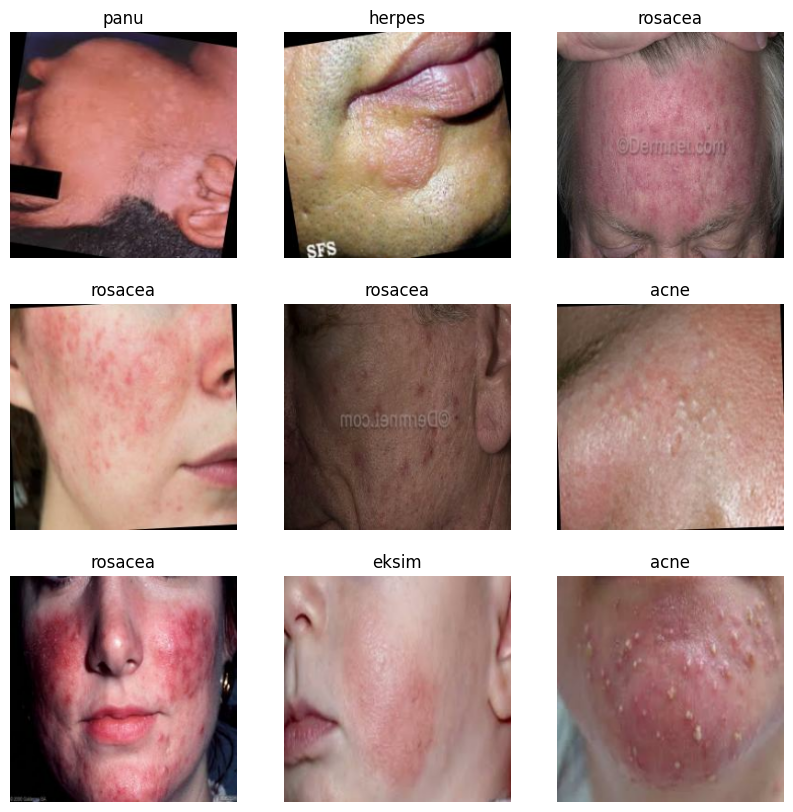

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Take one batch of 32 images
for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        # Convert tensor to numpy array and show as integer
        plt.imshow(images[i].numpy().astype("uint8"))
        # Look up the class name using the label index
        plt.title(class_names[labels[i]])
        plt.axis("off")
    plt.show()

In [7]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal_and_vertical"),
  tf.keras.layers.RandomRotation(0.2),
  tf.keras.layers.RandomZoom(0.2),
])

In [8]:
num_classes = 5

model = tf.keras.Sequential([
  # Augmentation happens FIRST
  data_augmentation,

  # Then we rescale
  tf.keras.layers.Rescaling(1./255),

  # Then the rest of the CNN...
  tf.keras.layers.Conv2D(16, 3, padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Dropout(0.2), # Bonus: randomly hides neurons to further prevent overfitting

  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(num_classes)
])

In [9]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

print("Model compiled and ready for training!")

Model compiled and ready for training!


In [10]:
epochs = 10

# Train the model
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 131ms/step - accuracy: 0.2173 - loss: 2.0464 - val_accuracy: 0.2483 - val_loss: 1.5398
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.3450 - loss: 1.5197 - val_accuracy: 0.3523 - val_loss: 1.4952
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.3851 - loss: 1.4315 - val_accuracy: 0.4262 - val_loss: 1.3632
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.4094 - loss: 1.3352 - val_accuracy: 0.3960 - val_loss: 1.4343
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.4424 - loss: 1.3274 - val_accuracy: 0.4094 - val_loss: 1.3326
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.4489 - loss: 1.2750 - val_accuracy: 0.4899 - val_loss: 1.2145
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.4718 - loss: 1.1993 - val_accuracy: 0.4597 - val_loss: 1.2417
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.5082 - loss: 1.1746 - val_accuracy: 0.5738 -

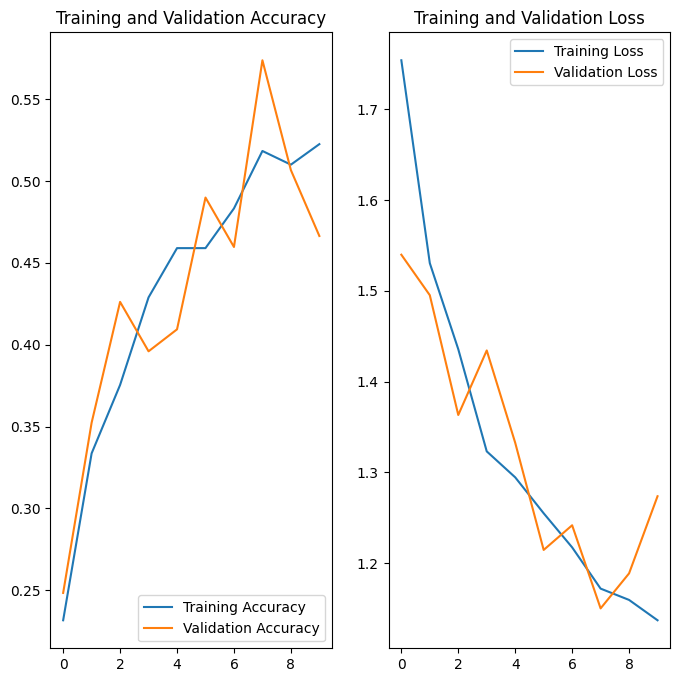

In [11]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [12]:
# 1. Download the pre-trained "Expert" (MobileNetV2)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(img_height, img_width, 3),
    include_top=False, # Drop the original classification layer
    weights='imagenet'
)

# # 2. "Freeze" the base model
# base_model.trainable = False

# # 3. Build the new model
# inputs = tf.keras.Input(shape=(img_height, img_width, 3))
# x = data_augmentation(inputs)
# x = tf.keras.layers.Rescaling(1./127.5, offset=-1)(x) # Scale to [-1, 1] for MobileNet
# x = base_model(x, training=False)
# x = tf.keras.layers.GlobalAveragePooling2D()(x) # Condense the features
# x = tf.keras.layers.Dropout(0.2)(x)
# outputs = tf.keras.layers.Dense(num_classes)(x)

# model = tf.keras.Model(inputs, outputs)

# print("Transfer Learning model built!")

base_learning_rate = 0.0001

# Unfreeze the base model
base_model.trainable = True

# It has many layers, so let's freeze all but the last 30
print("Number of layers in the base model: ", len(base_model.layers))

fine_tune_at = 100

# Freeze all the layers before the `fine_tune_at` layer
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

# Re-compile the model with a VERY low learning rate
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              optimizer = tf.keras.optimizers.RMSprop(learning_rate=base_learning_rate/10),
              metrics=['accuracy'])

print("Model prepared for fine-tuning!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Number of layers in the base model:  154
Model prepared for fine-tuning!


In [13]:
initial_epochs = 10
history = model.fit(train_ds,
                    epochs=initial_epochs,
                    validation_data=val_ds)

Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - accuracy: 0.5356 - loss: 1.1286 - val_accuracy: 0.5537 - val_loss: 1.1052
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.5465 - loss: 1.0896 - val_accuracy: 0.5570 - val_loss: 1.0842
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.5782 - loss: 1.0624 - val_accuracy: 0.5772 - val_loss: 1.0704
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.5861 - loss: 1.0532 - val_accuracy: 0.5906 - val_loss: 1.0625
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.5802 - loss: 1.0423 - val_accuracy: 0.5973 - val_loss: 1.0558
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.5584 - loss: 1.0533 - val_accuracy: 0.6007 - val_loss: 1.0519
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.5730 - loss: 1.0472 - val_accuracy: 0.6007 - val_loss: 1.0493
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.5812 - loss: 1.0485 - val_accuracy: 0.6007 - v

In [14]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Get all labels and predictions from the validation set
all_labels = []
all_preds = []

for images, labels in val_ds:
    # Get the model's 'raw' output (logits)
    preds = model.predict(images)
    # Use argmax to get the index of the highest score (the predicted class)
    all_preds.extend(np.argmax(preds, axis=1))
    all_labels.extend(labels.numpy())

# 2. Create the confusion matrix
cm = confusion_matrix(all_labels, all_preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


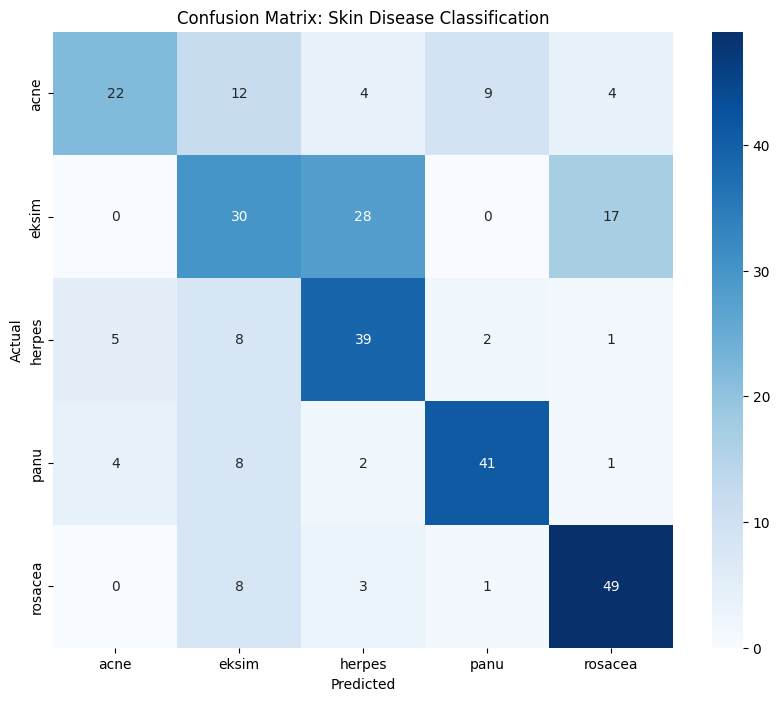

In [15]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Skin Disease Classification')
plt.show()

Saving download.jpg to download.jpg


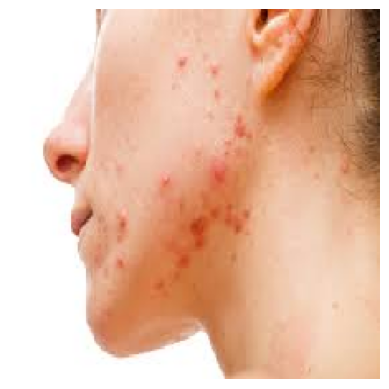

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step
This image most likely belongs to acne with a 41.76 percent confidence.


In [16]:
from google.colab import files
from tensorflow.keras.preprocessing import image

# 1. Upload the file
uploaded = files.upload()

for fn in uploaded.keys():
  # 2. Load and display the image
  path = '/content/' + fn
  img = image.load_img(path, target_size=(img_height, img_width))
  plt.imshow(img)
  plt.axis('off')
  plt.show()

  # 3. Convert image to array and add a 'batch' dimension
  img_array = image.img_to_array(img)
  img_array = tf.expand_dims(img_array, 0)

  # 4. Make the prediction
  predictions = model.predict(img_array)
  score = tf.nn.softmax(predictions[0])

  # 5. Print the result
  print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
  )

In [17]:
# 1. Use the same upload logic as before
for fn in uploaded.keys():
    img_path = '/content/' + fn
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    # 2. Get the raw predictions and turn them into probabilities
    predictions = model.predict(img_array)
    probabilities = tf.nn.softmax(predictions[0]).numpy()

    # 3. Get the indices of the top 3 predictions
    top_3_indices = probabilities.argsort()[-3:][::-1]

    print(f"\nResults for {fn}:")
    for i, idx in enumerate(top_3_indices):
        condition = class_names[idx]
        confidence = probabilities[idx] * 100
        print(f"{i+1}. {condition}: {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

Results for download.jpg:
1. acne: 41.76%
2. herpes: 26.23%
3. eksim: 16.75%
